In [2]:
import numpy as np 
from keras.datasets import mnist 
# Load the MNIST dataset 
(x_train, y_train), (x_test, y_test) = mnist.load_data() 
# Normalize pixel values between 0 and 1 
x_train = x_train.astype('float32') / 255. 
x_test = x_test.astype('float32') / 255. 
# Flatten the 28x28 images to 784-length vectors 
x_train = x_train.reshape((x_train.shape[0], -1)) 
x_test = x_test.reshape((x_test.shape[0], -1)) 
# Use a subset to speed up training 
subset_size = 10000 
x_train_subset = x_train[:subset_size] 
y_train_subset = y_train[:subset_size] 

In [3]:
from keras.models import Model 
from keras.layers import Input, Dense 
# Define the autoencoder structure 
input_img = Input(shape=(784,)) 
encoded = Dense(128, activation='relu')(input_img) 
encoded = Dense(64, activation='relu')(encoded) 
latent = Dense(32, activation='relu')(encoded) 
decoded = Dense(64, activation='relu')(latent) 
decoded = Dense(128, activation='relu')(decoded) 
decoded = Dense(784, activation='sigmoid')(decoded) 
# Autoencoder model 
autoencoder = Model(input_img, decoded) 
# Encoder model (for latent space extraction) 
encoder = Model(input_img, latent) 
# Compile and train 
autoencoder.compile(optimizer='adam', loss='mse') 
autoencoder.fit(x_train_subset, x_train_subset, 
epochs=10, batch_size=256, 
shuffle=True, validation_data=(x_test, x_test))

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.1159 - val_loss: 0.0729
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0697 - val_loss: 0.0651
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0607 - val_loss: 0.0565
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0531 - val_loss: 0.0492
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0448 - val_loss: 0.0410
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0388 - val_loss: 0.0378
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0361 - val_loss: 0.0360
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0338 - val_loss: 0.0337
Epoch 9/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0318 - val_loss: 0.0313
Epoch 10/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0301 - val_loss: 0.0299


In [4]:
from keras.utils import to_categorical 
from keras.layers import Dense 
# One-hot encode labels 
y_train_cat = to_categorical(y_train_subset, 10) 
y_test_cat = to_categorical(y_test, 10) 
# Define classifier model 
input_latent = Input(shape=(32,)) 
x = Dense(64, activation='relu')(input_latent) 
output = Dense(10, activation='softmax')(x) 
classifier_model = Model(input_latent, output) 
# Compile and train 
classifier_model.compile(optimizer='adam', loss='categorical_crossentropy', 
metrics=['accuracy']) 
# Extract latent features 
latent_train = encoder.predict(x_train_subset) 
latent_test = encoder.predict(x_test) 
# Train classifier 
classifier_model.fit(latent_train, y_train_cat, epochs=10, batch_size=256, 
validation_data=(latent_test, y_test_cat)) 

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 978us/step
Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2315 - loss: 3.7499 - val_accuracy: 0.4067 - val_loss: 1.7687
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5695 - loss: 1.3195 - val_accuracy: 0.6724 - val_loss: 1.0001
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7112 - loss: 0.8935 - val_accuracy: 0.7471 - val_loss: 0.8001
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7582 - loss: 0.7554 - val_accuracy: 0.7682 - val_loss: 0.7174
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7830 - loss: 0.6816 - val_accuracy: 0.7862 - val_loss: 0.6605
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7969 - loss: 0.6322 - val_accuracy: 0.7998 - val_loss: 0.6167
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8076 - loss: 0.6006 - val_accuracy: 0.8107 - val_loss: 0.5852
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━

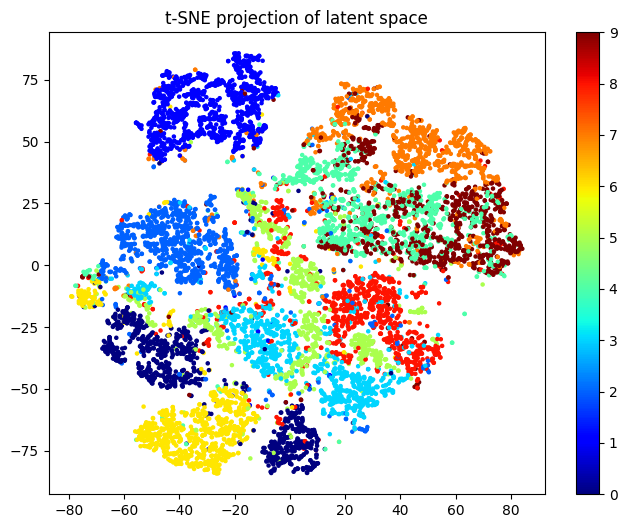

In [5]:
from sklearn.manifold import TSNE 
import matplotlib.pyplot as plt 
latent_2d = TSNE(n_components=2).fit_transform(latent_test) 
plt.figure(figsize=(8, 6)) 
plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=y_test, cmap='jet', s=5) 
plt.colorbar() 
plt.title("t-SNE projection of latent space") 
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


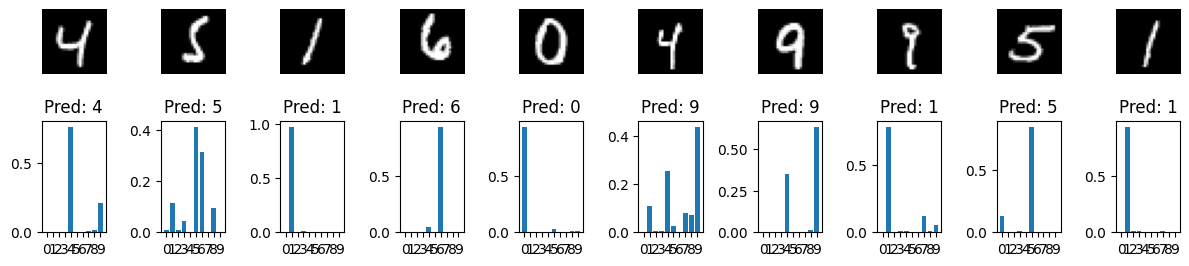

In [7]:
n = 10  # number of random images 
indices = np.random.choice(len(x_test), n) 
import matplotlib.pyplot as plt 
plt.figure(figsize=(12, 3)) 
for i, idx in enumerate(indices): 
    # Show original image 
    ax = plt.subplot(2, n, i + 1) 
    plt.imshow(x_test[idx].reshape(28, 28), cmap='gray') 
    plt.axis('off') 
    # Predict and show probabilities 
    pred = classifier_model.predict(latent_test[idx:idx+1]) 
    ax = plt.subplot(2, n, i + 1 + n) 
    plt.bar(np.arange(10), pred[0]) 
    plt.title(f"Pred: {np.argmax(pred)}") 
    plt.xticks(np.arange(10)) 
plt.tight_layout() 
plt.show()